# Food Price CPI — Data Exploration

A quick tour of the Canadian food CPI data used by the CFPR replica
experiment.  The target variable is the set of nine StatCan food sub-indices
from table 18-10-0004-11, which we register via the helper in
``food_price_forecasting.data``.

This notebook is intentionally short: the experiment notebook
(`food_cpi_experiment.ipynb`) is the canonical analysis.  Use this one as a
warm-up when you're onboarding, or when you want a look at the raw series
without touching the backtest.

If you need the macro covariates from FRED, register them yourself — see
``planning-docs/backlog.md`` for the deferred covariate-framing design work.

---
## 1. Load the 9 food CPI series

In [1]:
from __future__ import annotations

from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


ROOT = Path.cwd().resolve().parents[1]
STATCAN_CACHE = ROOT / "data" / "statcan"

from food_price_forecasting.data import CATEGORY_LABELS, FOOD_CPI_SERIES, build_food_cpi_service
from food_price_forecasting.plots import plot_food_cpi_small_multiples


svc = build_food_cpi_service(cache_dir=STATCAN_CACHE)
print(f"Registered {len(FOOD_CPI_SERIES)} food CPI series.")

_as_of = datetime.now(tz=timezone.utc).replace(tzinfo=None)
overall = svc.get_series("cpi_food_canada", as_of=_as_of)
print(f"cpi_food_canada: {overall['timestamp'].min()} → {overall['timestamp'].max()} ({len(overall)} months)")

Registered 9 food CPI series.
cpi_food_canada: 1949-01-01 00:00:00 → 2026-02-01 00:00:00 (926 months)


---
## 2. Visualise all nine sub-indices

Index levels (base 2002 = 100) give a single-glance view of the acceleration
in Canadian food prices since roughly 2020.

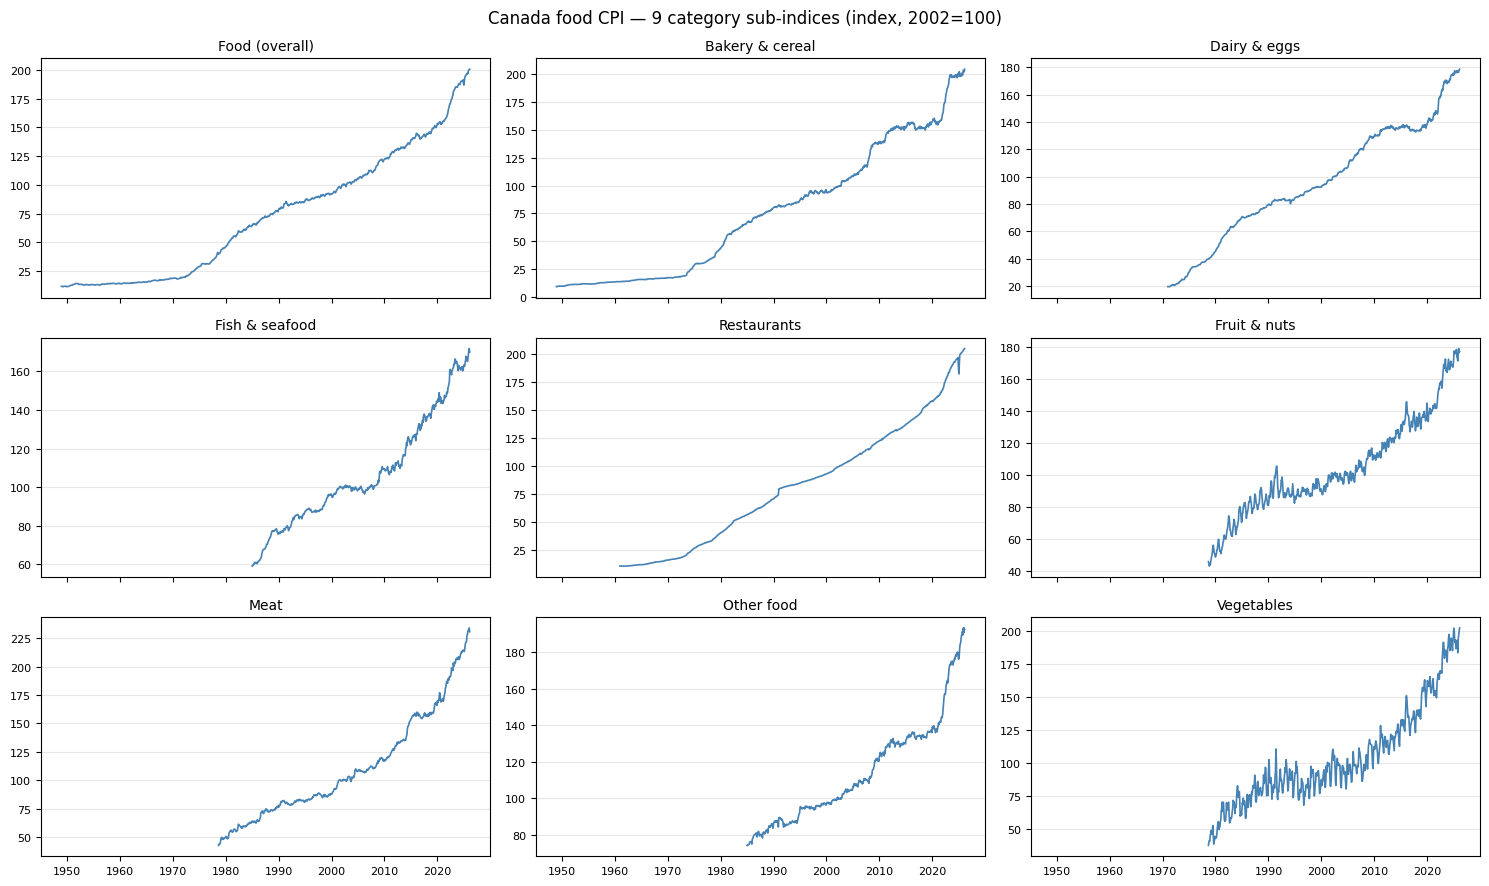

In [2]:
fig, _ = plot_food_cpi_small_multiples(svc)
plt.show()

---
## 3. Year-over-year change

Monthly YoY change surfaces the dynamics a predictor actually has to learn.
Most categories oscillate around ±5%; fish, vegetables, and fruit stand out for
higher volatility.

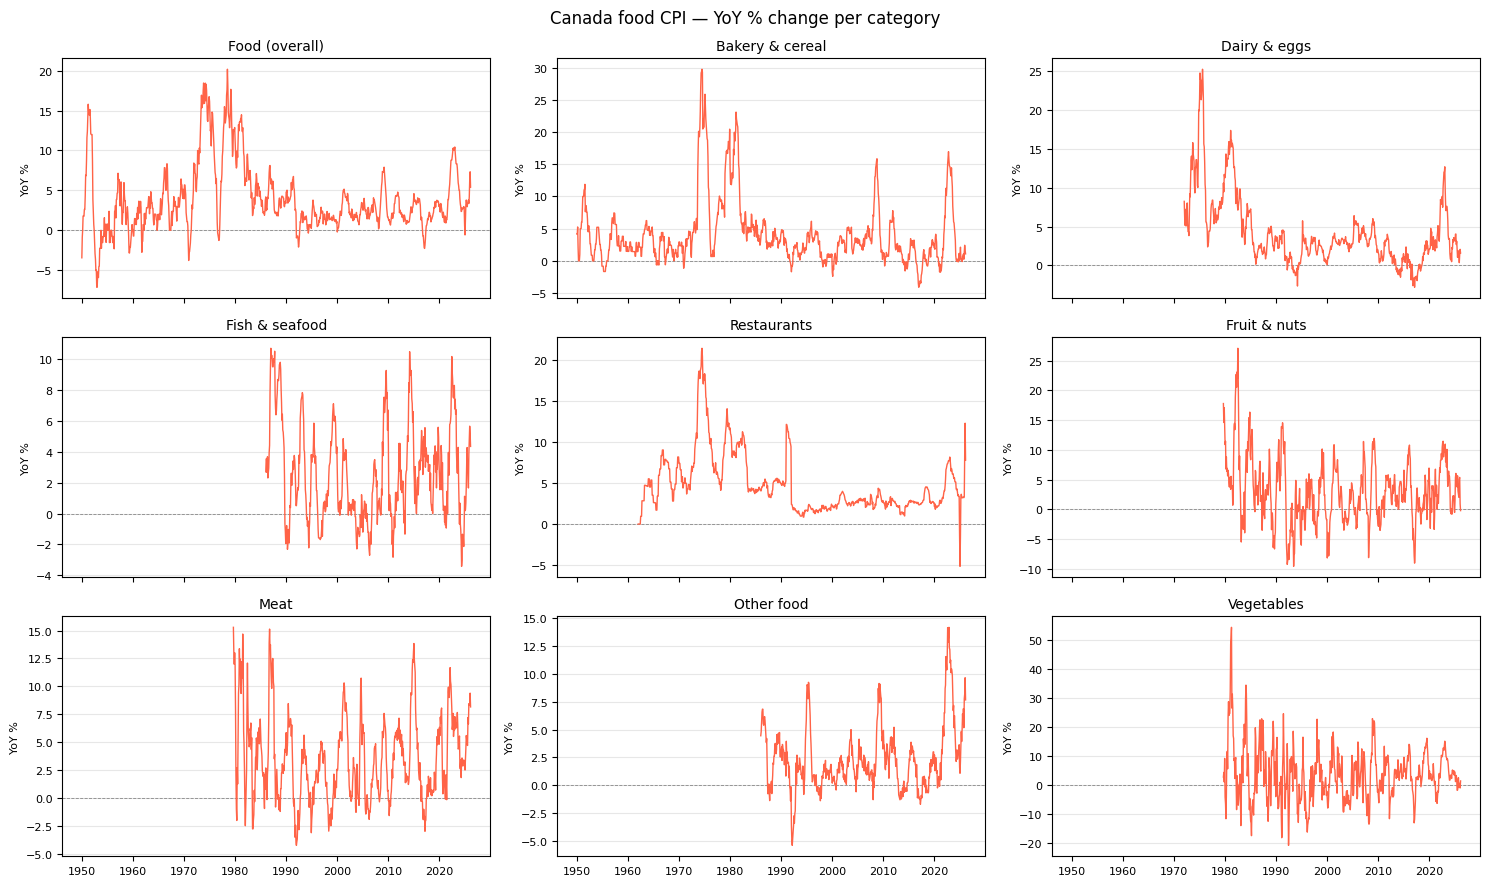

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(15, 9), sharex=True)
axes_flat = axes.flatten()

for ax, (series_id, _, _desc, _units) in zip(axes_flat, FOOD_CPI_SERIES):
    df = svc.get_series(series_id, as_of=_as_of)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.set_index("timestamp").sort_index()
    df["yoy_pct"] = df["value"].pct_change(12) * 100

    ax.axhline(0, color="#888", linewidth=0.6, linestyle="--")
    ax.plot(df.index, df["yoy_pct"], color="tomato", linewidth=1.0)
    ax.set_title(CATEGORY_LABELS.get(series_id, series_id), fontsize=10)
    ax.set_ylabel("YoY %", fontsize=8)
    ax.tick_params(labelsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Canada food CPI — YoY % change per category", fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. Coverage summary

In [4]:
rows: list[dict[str, object]] = []
for series_id, _, desc, units in FOOD_CPI_SERIES:
    df = svc.get_series(series_id, as_of=_as_of)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    rows.append(
        {
            "series_id": series_id,
            "description": desc,
            "units": units,
            "start": df["timestamp"].min().date(),
            "end": df["timestamp"].max().date(),
            "n_months": len(df),
        }
    )

coverage = pd.DataFrame(rows).set_index("series_id")
print(coverage.to_string())

                                                                                            description           units       start         end  n_months
series_id                                                                                                                                                
cpi_food_canada                                                   CPI Food (overall), Canada (2002=100)  Index 2002=100  1949-01-01  2026-02-01       926
cpi_bakery_cereal_canada            CPI Bakery and cereal products (excl. baby food), Canada (2002=100)  Index 2002=100  1949-01-01  2026-02-01       926
cpi_dairy_eggs_canada                                    CPI Dairy products and eggs, Canada (2002=100)  Index 2002=100  1971-01-01  2026-02-01       662
cpi_fish_seafood_canada                  CPI Fish, seafood and other marine products, Canada (2002=100)  Index 2002=100  1985-01-01  2026-02-01       494
cpi_restaurants_canada                           CPI Food purchased from res